In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
import eodgdl
import informal_jobs_model as ijm
from informal_jobs_model import od_sector
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

/Users/gperaza/Research/informal-jobs-model/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Economic activity (giro) imputation for OD workers

A substantial share of OD workers did not report the activity of the business they work for (`giro_empresa`). This stage estimates

$$P(G = g \mid X)$$

for the five native answers of the survey — Comercio, Servicio, Educación, Industria, Gobierno/sector público — from OD-only predictors, and keeps the whole probability vector rather than a hard assignment.

The model lives in the self-contained subpackage `informal_jobs_model.od_sector`: it reads the cleaned survey directly through `eodgdl.load_eod()`, uses the raw survey columns (no ENOE harmonization), attaches the work-trip destination and its DENUE establishment mix (via `mxcensus`), and predicts the survey's own giro levels. Its output is then *collapsed* to the four harmonized sector classes used by the informality model (`sector.yaml` `od_giro`, a many-to-one map, so the collapse is lossless) at the end of this notebook. This is the contract under which the model can move to `eodgdl` unchanged.

In [2]:
od = od_sector.build_worker_features(eodgdl.load_eod())
print(f"OD workers: {len(od):,}")
print(f"Workers with known giro: {(~od['giro_desconocido']).sum():,}")
print(f"Workers with unknown giro: {od['giro_desconocido'].sum():,}")
print(od["giro"].value_counts(dropna=False).rename(index=od_sector.GIRO_LABELS).to_string())

OD workers: 26,913
Workers with known giro: 17,429
Workers with unknown giro: 9,484
giro
NaN                        9484
Servicio                   6110
Comercio                   5868
Industria                  4551
Gobierno/sector público     638
Educación                   262


## Giro missingness profiles

Weighted characteristics of workers with and without an observed giro: the training population differs from the imputation target, which motivates the covariate-shift sensitivity check at the end.

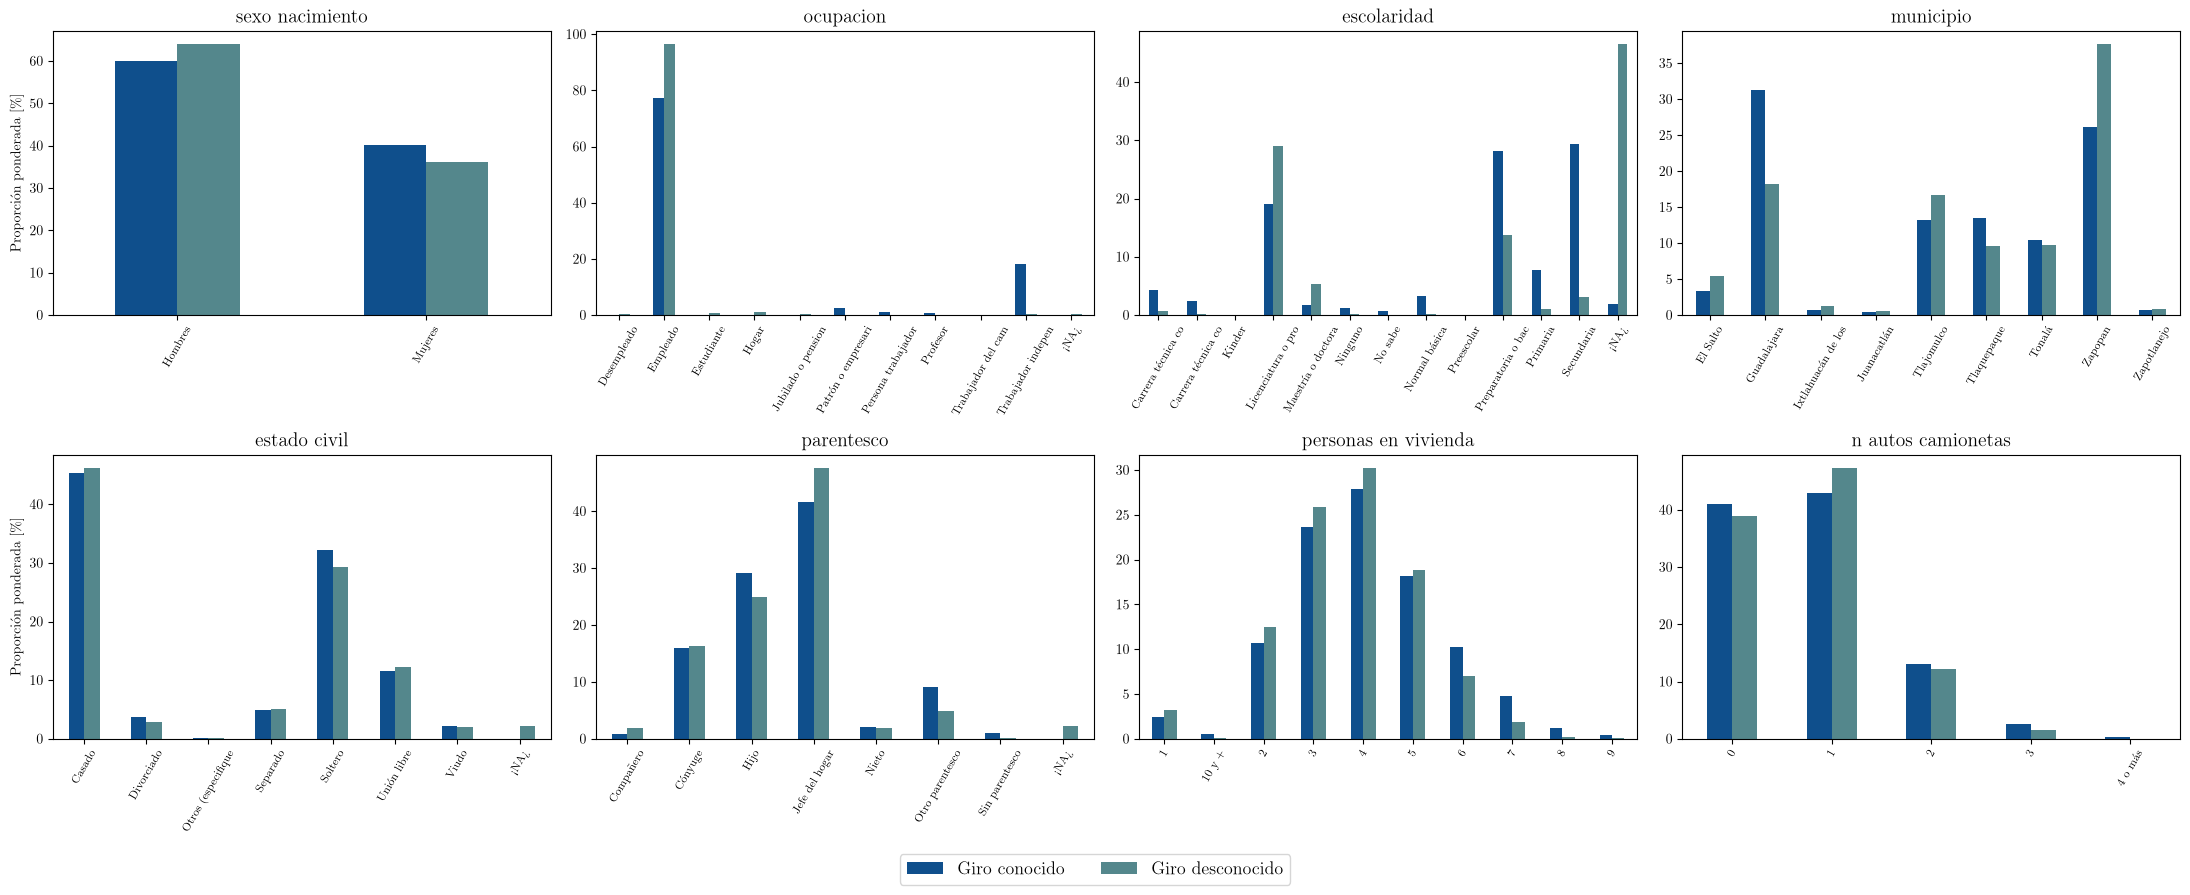

In [3]:
profile_columns = ["sexo_nacimiento", "ocupacion", "escolaridad", "municipio", "estado_civil", "parentesco", "personas_en_vivienda", "n_autos_camionetas"]
missingness_profiles = od_sector.compare_known_unknown_profiles(od, profile_columns)

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
for i, (ax, variable) in enumerate(zip(axes.flatten(), profile_columns)):
    plot_data = missingness_profiles[missingness_profiles["variable"] == variable].set_index("category")[["known_share", "unknown_share"]] * 100
    plot_data.index = [str(label)[:18] for label in plot_data.index]
    plot_data.plot(kind="bar", ax=ax, color=[(0.06, 0.31, 0.55), (0.33, 0.53, 0.55)])
    ax.set_title(variable.replace("_", " "), fontsize=14); ax.set_xlabel("")
    ax.set_ylabel(r"Proporción ponderada [\%]" if i in (0, 4) else "")
    ax.tick_params(axis="x", rotation=60, labelsize=8); ax.get_legend().remove()
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["Giro conocido", "Giro desconocido"], loc="lower center", ncol=2, fontsize=13, bbox_to_anchor=(0.5, 0.0))
output_dir = ROOT / "outputs/figures"; output_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(output_dir / "sector_known_unknown_profiles.pdf", bbox_inches="tight"); fig.savefig(output_dir / "sector_known_unknown_profiles.png", dpi=600, bbox_inches="tight")
plt.show()

## Predictors

Two specifications: with education (`SECTOR_FEATURES`) and without (`ROBUST_SECTOR_FEATURES`, for the workers whose education is unobserved). Besides the person and dwelling attributes, the model uses OD-specific information without ENOE counterparts: the raw occupation and employment status, the dwelling's centrality, the work trip (destination type, mode, weekend work travel, household vehicles) and the destination's ámbito and DENUE establishment mix.

In [4]:
with_education_features = od_sector.SECTOR_FEATURES
without_education_features = od_sector.ROBUST_SECTOR_FEATURES
print("With education:", *with_education_features, sep="\n  ")
print("\nWithout education drops:", sorted(set(with_education_features) - set(without_education_features)))
od_sector.calculate_feature_missingness(od, features=with_education_features).round(4)

With education:
  sexo_nacimiento
  edad
  escolaridad
  municipio
  estado_civil
  parentesco
  personas_en_vivienda
  ocupacion
  trabajo_semana_pasada
  centralidad
  destino_trabajo
  destino_ambito
  dest_establecimientos_log
  dest_share_grandes
  dest_share_comercio
  dest_share_servicio
  dest_share_educacion
  dest_share_industria
  dest_share_gobierno
  modo_trabajo
  weekend_dest_trabajar
  n_autos_camionetas

Without education drops: ['escolaridad']


,variable,known_missing_share,unknown_missing_share
0,sexo_nacimiento,0.0000,0.0000
1,edad,0.0000,0.0000
2,escolaridad,0.0184,0.4648
3,municipio,0.0000,0.0000
4,estado_civil,0.0000,0.0218
5,parentesco,0.0000,0.0218
6,personas_en_vivienda,0.0000,0.0000
7,ocupacion,0.0000,0.0029
8,trabajo_semana_pasada,0.0000,0.0000
9,centralidad,0.0000,0.0000


## Household-grouped train-test split

Workers with an observed giro are split 80/20 by household (`StratifiedGroupKFold`, fold 0 held out), so members of the same dwelling never straddle the split.

In [5]:
train, test = od_sector.split_known_data(od, n_splits=5, test_fold=0, random_state=42)
print(f"Training workers: {len(train):,} in {train['folio_vivienda'].nunique():,} households")
print(f"Test workers: {len(test):,} in {test['folio_vivienda'].nunique():,} households")

Training workers: 13,944 in 8,129 households
Test workers: 3,485 in 2,034 households


## Model A: with education

Three families are tuned under a 5-fold household-grouped CV with expansion-factor weights; within each family, and then across families, the simplest configuration within one standard error of the best log loss is selected.

In [6]:
from IPython.display import Markdown
models = od_sector.build_models()
lines = [f"* **{name}** — tuned: " + ", ".join(f"`{key.replace('classifier__', '')}`: {values}" for key, values in config["params"].items()) for name, config in models.items()]
total = sum(int(__import__("math").prod(len(v) for v in c["params"].values())) for c in models.values())
display(Markdown("\n".join(lines) + f"\n\n{total} configurations × 5 folds = {total * 5} fits per specification."))

* **LogisticRegression** — tuned: `C`: [0.1, 1.0, 10.0]
* **RandomForest** — tuned: `max_leaf_nodes`: [25, 50, 100], `max_features`: ['sqrt', 0.7], `min_samples_leaf`: [1, 5, 10]
* **GradientBoosting** — tuned: `max_iter`: [50, 100, 200, 400], `learning_rate`: [0.05, 0.1], `max_leaf_nodes`: [15, 31], `l2_regularization`: [0.0, 1.0]

53 configurations × 5 folds = 265 fits per specification.

In [7]:
X_a, y_a, w_a, g_a, _ = od_sector.prepare_training_data(train, features=with_education_features)
with_education_summary, with_education_models = od_sector.tune_models(X_a, y_a, w_a, g_a, features=with_education_features, cv_splits=5, random_state=42)
with_education_summary

,model,weighted_log_loss,weighted_log_loss_std,weighted_balanced_accuracy,weighted_accuracy,weighted_f1_macro,best_params,fold_log_losses,mean_diff_vs_best,se_diff_vs_best,within_one_se,complexity_rank,selected
0,GradientBoosting,0.909704,0.018058,0.511755,0.628336,0.539784,"{'classifier__l2_regularization': 1.0, 'classi...","[0.9120098590134499, 0.9054227097203166, 0.878...",0.000000,0.000000,True,3,True
1,RandomForest,0.925092,0.021719,0.496870,0.607748,0.509230,"{'classifier__max_features': 0.7, 'classifier_...","[0.9310347630288628, 0.9178662305358044, 0.886...",0.015387,0.002072,False,2,False
2,LogisticRegression,0.940062,0.018885,0.474477,0.604571,0.498522,{'classifier__C': 0.1},"[0.9423557617988745, 0.9351869506265711, 0.906...",0.030358,0.001392,False,1,False


In [8]:
with_education_best_name, with_education_best_model = od_sector.get_best_model(with_education_summary, with_education_models)
print(f"Selected: {with_education_best_name}", with_education_summary.loc[with_education_summary["selected"], "best_params"].iloc[0])
od_sector.fold_table(with_education_summary).round(4)

Selected: GradientBoosting {'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 50, 'classifier__max_leaf_nodes': 31}


,fold_0,fold_1,fold_2,fold_3,fold_4,mean,sd_across_folds
GradientBoosting,0.9120,0.9054,0.8781,0.9218,0.9312,0.9097,0.0202
RandomForest,0.9310,0.9179,0.8868,0.9411,0.9486,0.9251,0.0243
LogisticRegression,0.9424,0.9352,0.9068,0.9573,0.9587,0.9401,0.0211


In [9]:
with_education_metrics, with_education_class_metrics, with_education_confusion, with_education_distribution = od_sector.evaluate_model(with_education_best_model, test, features=with_education_features)
with_education_uncertainty = od_sector.test_metrics_with_uncertainty(with_education_best_model, test, features=with_education_features)
display(with_education_metrics.round(4)); display(with_education_uncertainty.round(4)); display(with_education_class_metrics.round(4)); display(with_education_distribution.round(4))

,accuracy,balanced_accuracy,f1_macro,weighted_accuracy,weighted_balanced_accuracy,weighted_f1_macro,weighted_log_loss
0,0.6445,0.5141,0.5413,0.6432,0.533,0.5539,0.8824


,estimate,ci_low,ci_high,bootstrap_sd
weighted_log_loss,0.8824,0.8447,0.9219,0.0203
marginal_log_loss,1.2882,1.2565,1.3180,0.0155
weighted_accuracy,0.6432,0.6185,0.6662,0.0119
weighted_f1_macro,0.5539,0.5116,0.5952,0.0217
relative_improvement_over_marginal,0.3150,NaN,NaN,NaN


,giro,precision,recall,f1,weighted_support
0,comercio,0.6776,0.7327,0.7040,108941.0
1,servicio,0.5894,0.5625,0.5757,112331.0
2,educacion,0.5540,0.4207,0.4782,5375.0
3,industria,0.6773,0.7194,0.6977,83879.0
4,gobierno,0.4963,0.2296,0.3139,14238.0


,giro,observed_population,observed_share,hard_predicted_population,hard_predicted_share,probabilistic_predicted_population,probabilistic_predicted_share,probabilistic_difference_pp
0,comercio,108941.0,0.3354,117801.0,0.3627,110069.4494,0.3389,0.3475
1,servicio,112331.0,0.3459,107202.0,0.3301,111279.8262,0.3426,-0.3237
2,educacion,5375.0,0.0166,4081.0,0.0126,5075.3973,0.0156,-0.0923
3,industria,83879.0,0.2583,89093.0,0.2743,86316.2835,0.2658,0.7505
4,gobierno,14238.0,0.0438,6587.0,0.0203,12023.0436,0.0370,-0.6820


In [10]:
from IPython.display import Markdown
m = with_education_metrics.iloc[0]; u = with_education_uncertainty; cm = with_education_class_metrics.set_index("giro"); rare = cm["recall"].idxmin()
d = with_education_distribution.set_index("giro"); prob_gap = (d["probabilistic_predicted_share"] - d["observed_share"]).abs().max() * 100; hard_gap = (d["hard_predicted_share"] - d["observed_share"]).abs().max() * 100
display(Markdown(f"The selected **{with_education_best_name}** reaches a weighted accuracy of {m['weighted_accuracy']:.1%} on the held-out households (95% household-bootstrap interval {u.loc['weighted_accuracy', 'ci_low']:.1%}–{u.loc['weighted_accuracy', 'ci_high']:.1%}) and a weighted log loss of {m['weighted_log_loss']:.4f}, {u.loc['relative_improvement_over_marginal', 'estimate']:.1%} below the weighted-marginal baseline ({u.loc['marginal_log_loss', 'estimate']:.4f}). "
    f"Performance is uneven across classes: `{rare}` (recall {cm.loc[rare, 'recall']:.1%}) is rarely selected by the hard classifier. Hard assignments distort the aggregate composition by up to {hard_gap:.1f} pp, whereas the probabilistic aggregation stays within {prob_gap:.1f} pp of the observed shares — the reason to keep the full probability vector."))

The selected **GradientBoosting** reaches a weighted accuracy of 64.3% on the held-out households (95% household-bootstrap interval 61.9%–66.6%) and a weighted log loss of 0.8824, 31.5% below the weighted-marginal baseline (1.2882). Performance is uneven across classes: `gobierno` (recall 23.0%) is rarely selected by the hard classifier. Hard assignments distort the aggregate composition by up to 2.7 pp, whereas the probabilistic aggregation stays within 0.8 pp of the observed shares — the reason to keep the full probability vector.

## Model B: without education

In [11]:
X_b, y_b, w_b, g_b, _ = od_sector.prepare_training_data(train, features=without_education_features)
without_education_summary, without_education_models = od_sector.tune_models(X_b, y_b, w_b, g_b, features=without_education_features, cv_splits=5, random_state=42)
without_education_best_name, without_education_best_model = od_sector.get_best_model(without_education_summary, without_education_models)
print(f"Selected: {without_education_best_name}", without_education_summary.loc[without_education_summary["selected"], "best_params"].iloc[0])
display(without_education_summary); display(od_sector.fold_table(without_education_summary).round(4))

Selected: GradientBoosting {'classifier__l2_regularization': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_iter': 50, 'classifier__max_leaf_nodes': 31}


,model,weighted_log_loss,weighted_log_loss_std,weighted_balanced_accuracy,weighted_accuracy,weighted_f1_macro,best_params,fold_log_losses,mean_diff_vs_best,se_diff_vs_best,within_one_se,complexity_rank,selected
0,GradientBoosting,0.926652,0.021955,0.498952,0.616135,0.529225,"{'classifier__l2_regularization': 1.0, 'classi...","[0.9404306232582881, 0.9230370032217705, 0.885...",0.000000,0.000000,True,3,True
1,RandomForest,0.933284,0.022650,0.501133,0.607314,0.514217,"{'classifier__max_features': 0.7, 'classifier_...","[0.9399531161839775, 0.9265834797900782, 0.892...",0.006632,0.002876,False,2,False
2,LogisticRegression,0.954455,0.020037,0.455451,0.595614,0.477760,{'classifier__C': 0.1},"[0.9580213325533778, 0.9504926687039388, 0.918...",0.027803,0.002752,False,1,False


,fold_0,fold_1,fold_2,fold_3,fold_4,mean,sd_across_folds
GradientBoosting,0.9404,0.9230,0.8858,0.9361,0.9479,0.9267,0.0245
RandomForest,0.9400,0.9266,0.8927,0.9530,0.9542,0.9333,0.0253
LogisticRegression,0.9580,0.9505,0.9186,0.9686,0.9766,0.9545,0.0224


In [12]:
without_education_metrics, without_education_class_metrics, without_education_confusion, without_education_distribution = od_sector.evaluate_model(without_education_best_model, test, features=without_education_features)
without_education_uncertainty = od_sector.test_metrics_with_uncertainty(without_education_best_model, test, features=without_education_features)
display(without_education_metrics.round(4)); display(without_education_uncertainty.round(4)); display(without_education_class_metrics.round(4)); display(without_education_distribution.round(4))

,accuracy,balanced_accuracy,f1_macro,weighted_accuracy,weighted_balanced_accuracy,weighted_f1_macro,weighted_log_loss
0,0.6244,0.4885,0.5029,0.6199,0.4974,0.505,0.9078


,estimate,ci_low,ci_high,bootstrap_sd
weighted_log_loss,0.9078,0.8672,0.9477,0.0215
marginal_log_loss,1.2882,1.2565,1.3180,0.0155
weighted_accuracy,0.6199,0.5954,0.6421,0.0120
weighted_f1_macro,0.5050,0.4635,0.5539,0.0224
relative_improvement_over_marginal,0.2953,NaN,NaN,NaN


,giro,precision,recall,f1,weighted_support
0,comercio,0.6602,0.7123,0.6853,108941.0
1,servicio,0.5679,0.5381,0.5526,112331.0
2,educacion,0.3880,0.3727,0.3802,5375.0
3,industria,0.6570,0.7030,0.6792,83879.0
4,gobierno,0.3904,0.1609,0.2279,14238.0


,giro,observed_population,observed_share,hard_predicted_population,hard_predicted_share,probabilistic_predicted_population,probabilistic_predicted_share,probabilistic_difference_pp
0,comercio,108941.0,0.3354,117546.0,0.3619,109759.9548,0.3380,0.2522
1,servicio,112331.0,0.3459,106429.0,0.3277,112017.8521,0.3449,-0.0964
2,educacion,5375.0,0.0166,5162.0,0.0159,5097.8426,0.0157,-0.0853
3,industria,83879.0,0.2583,89758.0,0.2764,86512.6214,0.2664,0.8109
4,gobierno,14238.0,0.0438,5869.0,0.0181,11375.7290,0.0350,-0.8813


In [13]:
from IPython.display import Markdown
a = with_education_metrics.iloc[0]; b = without_education_metrics.iloc[0]
display(Markdown(f"Without education, weighted accuracy moves from {a['weighted_accuracy']:.1%} to {b['weighted_accuracy']:.1%} and the weighted log loss from {a['weighted_log_loss']:.4f} to {b['weighted_log_loss']:.4f} ({without_education_uncertainty.loc['relative_improvement_over_marginal', 'estimate']:.1%} below the marginal baseline instead of {with_education_uncertainty.loc['relative_improvement_over_marginal', 'estimate']:.1%}). Model B is a reasonable fallback for the workers whose education is unobserved."))
model_comparison = pd.concat([with_education_metrics.assign(features="Con escolaridad"), without_education_metrics.assign(features="Sin escolaridad")], ignore_index=True)
model_comparison[["features", "weighted_accuracy", "weighted_balanced_accuracy", "weighted_f1_macro", "weighted_log_loss"]].round(4)

Without education, weighted accuracy moves from 64.3% to 62.0% and the weighted log loss from 0.8824 to 0.9078 (29.5% below the marginal baseline instead of 31.5%). Model B is a reasonable fallback for the workers whose education is unobserved.

,features,weighted_accuracy,weighted_balanced_accuracy,weighted_f1_macro,weighted_log_loss
0,Con escolaridad,0.6432,0.5330,0.5539,0.8824
1,Sin escolaridad,0.6199,0.4974,0.5050,0.9078


### Calibration of the giro probabilities

One-vs-rest reliability of each class on the held-out households: the imputation is probabilistic, so what matters is whether the probabilities are honest.

Calibration in the large — with education
     giro  observed_share  predicted_share  gap_pp    ece  calibration_slope
 comercio          0.3354           0.3389  0.3475 0.0241             1.0934
educacion          0.0166           0.0156 -0.0923 0.0061             1.0467
 gobierno          0.0438           0.0370 -0.6820 0.0087             1.0274
industria          0.2583           0.2658  0.7505 0.0352             1.1211
 servicio          0.3459           0.3426 -0.3237 0.0244             1.0594

Calibration in the large — without education
     giro  observed_share  predicted_share  gap_pp    ece  calibration_slope
 comercio          0.3354           0.3380  0.2522 0.0216             1.0771
educacion          0.0166           0.0157 -0.0853 0.0058             0.9777
 gobierno          0.0438           0.0350 -0.8813 0.0141             0.9241
industria          0.2583           0.2664  0.8109 0.0260             1.1039
 servicio          0.3459           0.3449 -0.0964 0.0162        

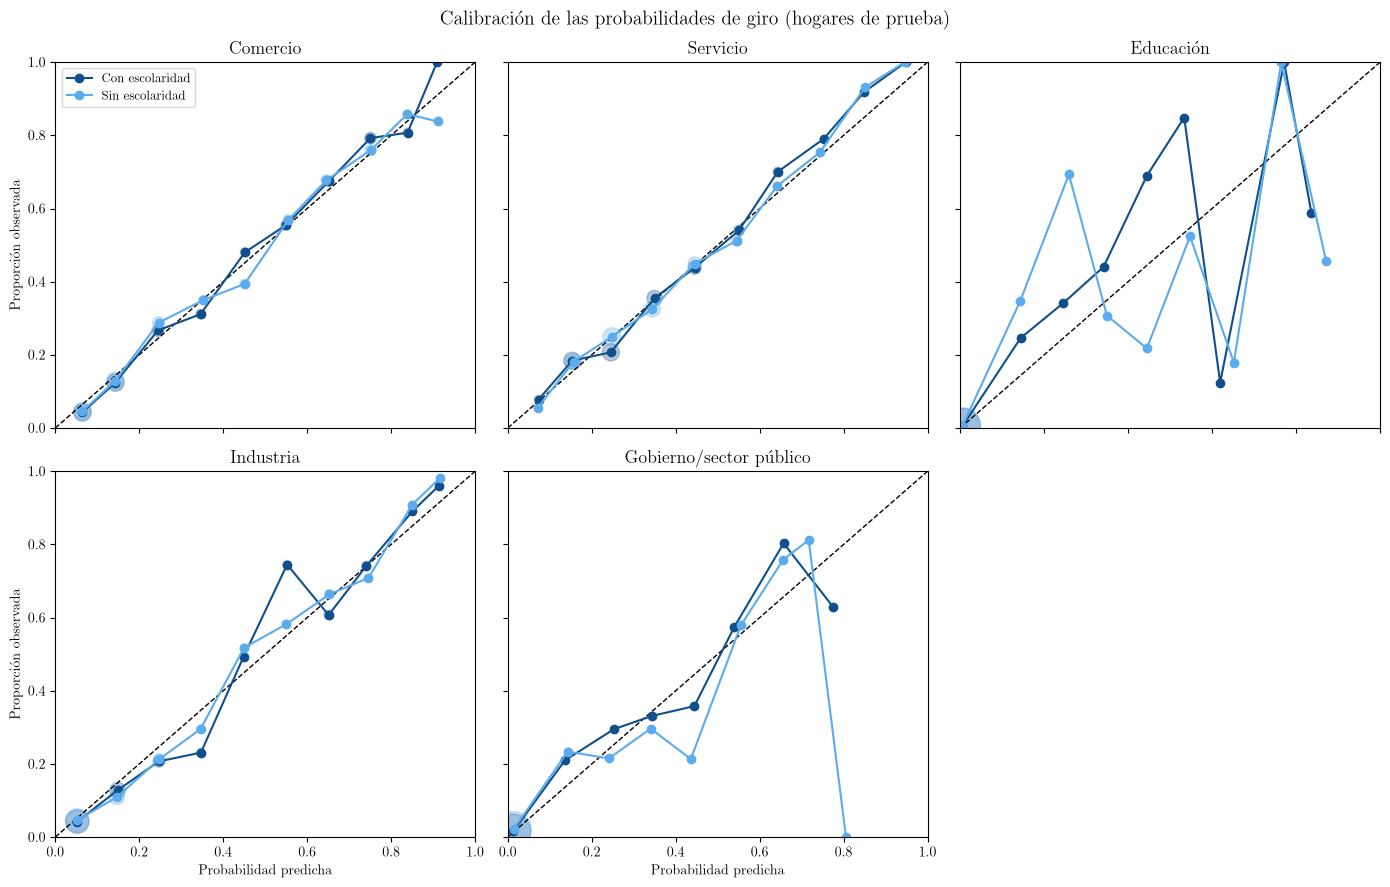

In [14]:
with_education_calibration, with_education_reliability = od_sector.calculate_calibration(with_education_best_model, test, features=with_education_features)
without_education_calibration, without_education_reliability = od_sector.calculate_calibration(without_education_best_model, test, features=without_education_features)
print("Calibration in the large — with education"); print(with_education_calibration.round(4).to_string(index=False))
print("\nCalibration in the large — without education"); print(without_education_calibration.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)
for ax, giro in zip(axes.ravel(), od_sector.GIRO_CLASSES):
    ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    for label, reliability, color in (("Con escolaridad", with_education_reliability, (0.06, 0.31, 0.55)), ("Sin escolaridad", without_education_reliability, (0.36, 0.67, 0.93))):
        curve = reliability[reliability["giro"] == giro]
        ax.plot(curve["predicted_probability"], curve["observed_rate"], marker="o", color=color, label=label)
        ax.scatter(curve["predicted_probability"], curve["observed_rate"], s=curve["sample_workers"] / 5, color=color, alpha=0.3)
    ax.set_title(od_sector.GIRO_LABELS[giro], fontsize=13); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[1, 2].axis("off"); axes[0, 0].legend(fontsize=9)
for ax in axes[1, :2]: ax.set_xlabel("Probabilidad predicha")
for ax in axes[:, 0]: ax.set_ylabel("Proporción observada")
fig.suptitle("Calibración de las probabilidades de giro (hogares de prueba)", fontsize=14)
plt.tight_layout()
fig.savefig(output_dir / "sector_calibration.pdf", bbox_inches="tight"); fig.savefig(output_dir / "sector_calibration.png", dpi=600, bbox_inches="tight")
plt.show()

## Hybrid model: refit and imputation

Both selected specifications are refitted on every worker with an observed giro. Workers without a giro are scored by Model A when their education is observed and by Model B otherwise. Workers without a work trip on the survey day have no destination: they are marginalized over destination types with their own conditional distribution P(destino | x) from an auxiliary model, and any categorical level without training support is marginalized over the supported levels (`giro_marginalized_features` records where this happened).

In [15]:
final_with_education_model, final_training = od_sector.refit_model(with_education_best_model, od, features=with_education_features)
final_without_education_model, _ = od_sector.refit_model(without_education_best_model, od, features=without_education_features)
destination_models = od_sector.fit_destination_models(od, with_education_features=with_education_features, without_education_features=without_education_features)
od_giro = od_sector.impute_giro(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features, destination_models=destination_models)
print(f"Final training workers: {len(final_training):,}; imputed workers: {od_giro['giro_fue_imputado'].sum():,}; without final giro: {od_giro['giro_final'].isna().sum():,}")
print(f"Maximum probability-sum error: {od_sector.validate_probability_rows(od_giro):.3e}")
display(od_sector.calculate_model_usage(od_giro).round(4)); display(od_sector.calculate_confidence_summary(od_giro).round(4))
print("Imputed rows with categorical levels absent from the training data:")
display(od_sector.count_levels_without_training_support(od_sector.prepare_model_features(od[~od["giro_desconocido"]], with_education_features), od_sector.prepare_model_features(od[od["giro_desconocido"]], with_education_features)))

Final training workers: 17,429; imputed workers: 9,484; without final giro: 0
Maximum probability-sum error: 3.331e-16


,giro_model_used,sample_workers,weighted_population,sample_share,weighted_share
0,with_education,4962,366704,0.5232,0.5346
1,without_education,4522,319242,0.4768,0.4654


,giro_model_used,count,mean,std,min,median,max
0,with_education,4962,0.6042,0.1299,0.2792,0.6075,0.9558
1,without_education,4522,0.6542,0.1340,0.2631,0.6555,0.9615


Imputed rows with categorical levels absent from the training data:


,feature,rows,levels
0,estado_civil,106,[no_especificado]
1,parentesco,105,[no_especificado]
2,ocupacion,222,"[Desempleado, Estudiante, Hogar, Jubilado o pe..."


,observed_known_share,imputed_share,hard_imputed_share,final_share
giro,,,,
comercio,33.36,24.84,25.69,30.79
servicio,34.84,35.61,34.34,35.07
educacion,1.59,1.31,0.93,1.50
industria,26.16,32.39,35.08,28.04
gobierno,4.05,5.85,3.96,4.60


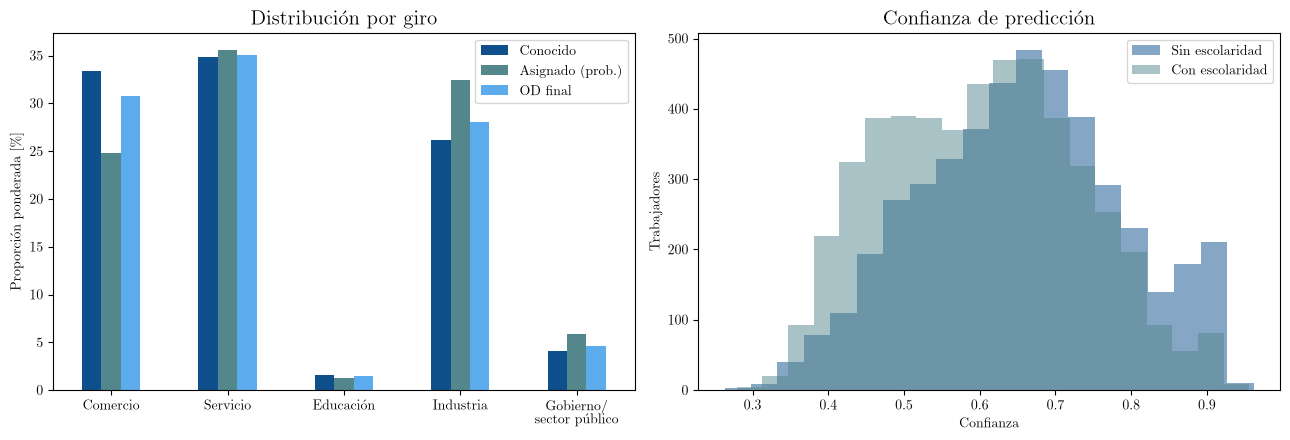

In [16]:
imputed_workers = od_giro[od_giro["giro_fue_imputado"]]
observed_distribution = od_sector.calculate_distribution(od[~od["giro_desconocido"]], giro_column="giro")
hard_imputed = od_sector.calculate_distribution(imputed_workers); probabilistic_imputed = od_sector.calculate_probabilistic_distribution(imputed_workers)
hard_final = od_sector.calculate_distribution(od_giro); probabilistic_final = od_sector.calculate_probabilistic_distribution(od_giro)

comparison = observed_distribution[["giro", "weighted_share"]].rename(columns={"weighted_share": "observed_known_share"})
comparison = comparison.merge(probabilistic_imputed[["giro", "weighted_share"]].rename(columns={"weighted_share": "imputed_share"}), on="giro", how="outer")
comparison = comparison.merge(hard_imputed[["giro", "weighted_share"]].rename(columns={"weighted_share": "hard_imputed_share"}), on="giro", how="outer")
comparison = comparison.merge(probabilistic_final[["giro", "weighted_share"]].rename(columns={"weighted_share": "final_share"}), on="giro", how="outer").set_index("giro").reindex(od_sector.GIRO_CLASSES)
display((comparison * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_data = comparison[["observed_known_share", "imputed_share", "final_share"]] * 100
plot_data.index = [od_sector.GIRO_LABELS[g].replace("/", "/\n") for g in plot_data.index]
plot_data.plot(kind="bar", ax=axes[0], color=[(0.06, 0.31, 0.55), (0.33, 0.53, 0.55), (0.36, 0.67, 0.93)])
axes[0].set_title("Distribución por giro", fontsize=15); axes[0].set_xlabel(""); axes[0].set_ylabel(r"Proporción ponderada [\%]"); axes[0].tick_params(axis="x", rotation=0, labelsize=10)
axes[0].legend(["Conocido", "Asignado (prob.)", "OD final"], fontsize=10)
for key, color, label in (("without_education", (0.06, 0.31, 0.55), "Sin escolaridad"), ("with_education", (0.33, 0.53, 0.55), "Con escolaridad")):
    axes[1].hist(imputed_workers.loc[imputed_workers["giro_model_used"] == key, "giro_prediction_confidence"], bins=20, alpha=0.5, color=color, label=label)
axes[1].set_title("Confianza de predicción", fontsize=15); axes[1].set_xlabel("Confianza"); axes[1].set_ylabel("Trabajadores"); axes[1].legend()
plt.tight_layout()
fig.savefig(output_dir / "sector_final_distributions_confidence.pdf", bbox_inches="tight"); fig.savefig(output_dir / "sector_final_distributions_confidence.png", dpi=600, bbox_inches="tight")
plt.show()

### Sensitivity to the covariate shift

The model is validated on known-giro households but applied to the unknown-giro workers, who differ (more educated, more item non-response). Two checks: (i) refit the selected models on known-giro rows reweighted to the unknown-giro profile (density-ratio weights on the shift profile features, education excluded); (ii) a delta adjustment that scales the imputed probability of the minority class to the observed share. Both scenarios are saved (collapsed to sectors) for the informality stage's headline sensitivity table.

In [17]:
od_giro_shift, shift_diagnostics = od_sector.impute_under_covariate_shift(with_education_best_model, without_education_best_model, od, with_education_features=with_education_features, without_education_features=without_education_features)
od_giro_delta, delta_factor = od_sector.adjust_imputed_share(od_giro, "gobierno")
print("Shift-weighting diagnostics:"); print(shift_diagnostics.round(3).to_string())
print(f"\nDelta adjustment factor for gobierno among imputed workers: {delta_factor:.3f}")
imputed_shares = lambda frame: od_sector.calculate_probabilistic_distribution(frame[frame["giro_fue_imputado"]]).set_index("giro")["weighted_share"]
sensitivity = pd.DataFrame({"observed (known giro)": observed_distribution.set_index("giro")["weighted_share"], "imputed: current": imputed_shares(od_giro), "imputed: shift-weighted": imputed_shares(od_giro_shift), "imputed: delta-adjusted": imputed_shares(od_giro_delta)}).reindex(od_sector.GIRO_CLASSES)
print("\nGiro shares among imputed workers (weighted, %):"); print((sensitivity * 100).round(2))

Shift-weighting diagnostics:
rows                       17429.000
effective_sample_size       6820.462
top_decile_weight_share        0.190
odds_ratio_median              0.977
odds_ratio_p90                 2.250

Delta adjustment factor for gobierno among imputed workers: 0.693

Giro shares among imputed workers (weighted, %):
           observed (known giro)  imputed: current  imputed: shift-weighted  \
giro                                                                          
comercio                   33.36             24.84                    24.03   
servicio                   34.84             35.61                    34.88   
educacion                   1.59              1.31                     1.21   
industria                  26.16             32.39                    33.71   
gobierno                    4.05              5.85                     6.18   

           imputed: delta-adjusted  
giro                                
comercio                     25.15  
serv

## Outputs

`od_giro_imputed.parquet` is the giro model's own output (keys, `giro_*` columns and `prob_giro_<slug>`), the contract a future `eodgdl` release would provide. `od_sector_imputed.parquet` is that output collapsed to the harmonized sector classes and joined to `od_harmonized` (`ijm.attach_sector_probabilities`), the input of the informality stage; the two sensitivity scenarios are collapsed the same way.

In [18]:
output_directory = ROOT / "outputs"
giro_columns = od_sector.KEYS + ["giro_observado", "giro_imputado", "giro_final", "giro_fue_imputado", "giro_model_used", "giro_prediction_confidence", "giro_marginalized_features"] + od_sector.PROBABILITY_COLUMNS
od_giro[giro_columns].to_parquet(output_directory / "od_giro_imputed.parquet", index=False)

od_harmonized = pd.read_parquet(output_directory / "od_harmonized.parquet")
od_sector_imputed = ijm.attach_sector_probabilities(od_harmonized, od_giro[giro_columns])
od_sector_imputed.to_parquet(output_directory / "od_sector_imputed.parquet", index=False)
sensitivity_output = pd.concat([ijm.attach_sector_probabilities(od_harmonized, frame[giro_columns]).assign(scenario=name) for name, frame in (("shift_weighted", od_giro_shift), ("delta_adjusted", od_giro_delta))], ignore_index=True)
sensitivity_output.to_parquet(output_directory / "od_sector_imputed_sensitivity.parquet", index=False)

print("Final sector distribution after collapsing to the harmonized classes (weighted, %):")
sector_columns = [f"prob_sector_{s}" for s in ijm.SECTOR_CLASSES]
print(((od_sector_imputed[sector_columns].multiply(od_sector_imputed["expansion_factor"], axis=0).sum() / od_sector_imputed["expansion_factor"].sum()) * 100).round(2).to_string())

Final sector distribution after collapsing to the harmonized classes (weighted, %):
prob_sector_comercio                     30.79
prob_sector_gobierno_otro_agricultura      4.6
prob_sector_manufactura_construccion     28.04
prob_sector_servicios_transporte         36.57


In [19]:
from joblib import dump

models_directory = ROOT / "outputs/models"
models_directory.mkdir(parents=True, exist_ok=True)
sector_model_bundle = {
    "model_with_education": final_with_education_model,
    "model_without_education": final_without_education_model,
    "features_with_education": with_education_features,
    "features_without_education": without_education_features,
    "category_levels": od_sector.build_category_levels(),
    "giro_classes": od_sector.GIRO_CLASSES,
    "giro_labels": od_sector.GIRO_LABELS,
    "destination_models": destination_models,
    "metadata": {
        "selected": {"with_education": with_education_summary.loc[with_education_summary["selected"], ["model", "best_params", "weighted_log_loss"]].iloc[0].to_dict(), "without_education": without_education_summary.loc[without_education_summary["selected"], ["model", "best_params", "weighted_log_loss"]].iloc[0].to_dict()},
        "test_metrics": {"with_education": with_education_metrics.iloc[0].to_dict(), "without_education": without_education_metrics.iloc[0].to_dict()},
        "denue_release": od_sector.DENUE_RELEASE, "sklearn_version": __import__("sklearn").__version__, "random_state": 42,
    },
}
model_path = models_directory / "od_giro_hybrid_model.joblib"
dump(sector_model_bundle, model_path)
print(f"Saved: {model_path}")

Saved: /Users/gperaza/Research/informal-jobs-model/outputs/models/od_giro_hybrid_model.joblib
